### aim: 

### date: 

In [3]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [4]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


In [5]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')


## assorted snippets

#### AMOC timeseries

Saved to ./plts/AMOC_26N_timeseries_6runs.png


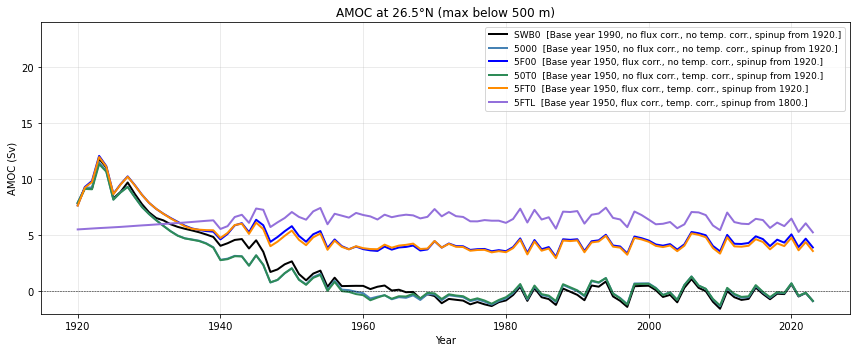

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# ===== INPUTS =====
clims_dir = '/gpfs/data/greenocean/users/mep22dku/clims/'
yrst      = 1920
yrend     = 2024

run_descriptions = {
    "SWB0": "Base year 1990, no flux corr., no temp. corr., spinup from 1920.",
    "5000": "Base year 1950, no flux corr., no temp. corr., spinup from 1920.",
    "5F00": "Base year 1950, flux corr., no temp. corr., spinup from 1920.",
    "50T0": "Base year 1950, no flux corr., temp. corr., spinup from 1920.",
    "5FT0": "Base year 1950, flux corr., temp. corr., spinup from 1920.",
    "5FTL": "Base year 1950, flux corr., temp. corr., spinup from 1800.",
}

colors = ['black', 'steelblue', 'b', 'seagreen', 'darkorange', 'mediumpurple']

# ===== PLOT =====
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('AMOC at 26.5°N (max below 500 m)')

for (run, desc), color in zip(run_descriptions.items(), colors):
    model = f'TOM12_TJ_{run}'
    fpath = Path(clims_dir) / model / f'{model}_AMOC_26N_{yrst}_{yrend}.nc'
    if fpath.exists():
        ds = xr.open_dataset(fpath, engine='netcdf4')
        da = ds['AMOC_26N'].groupby('time_counter.year').mean()
        ax.plot(da.year, da.values, color=color, linewidth=2, label=f'{run}  [{desc}]')
    else:
        print(f"Missing: {fpath}")

ax.set_ylabel('AMOC (Sv)')
ax.set_xlabel('Year')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim([-2, 24])

fig.tight_layout()
outfile = './plts/AMOC_26N_timeseries_6runs.png'
fig.savefig(outfile, dpi=150, bbox_inches='tight')
print(f"Saved to {outfile}")
plt.show()

## streamfunctions

✓ Using custom font: Gill Sans


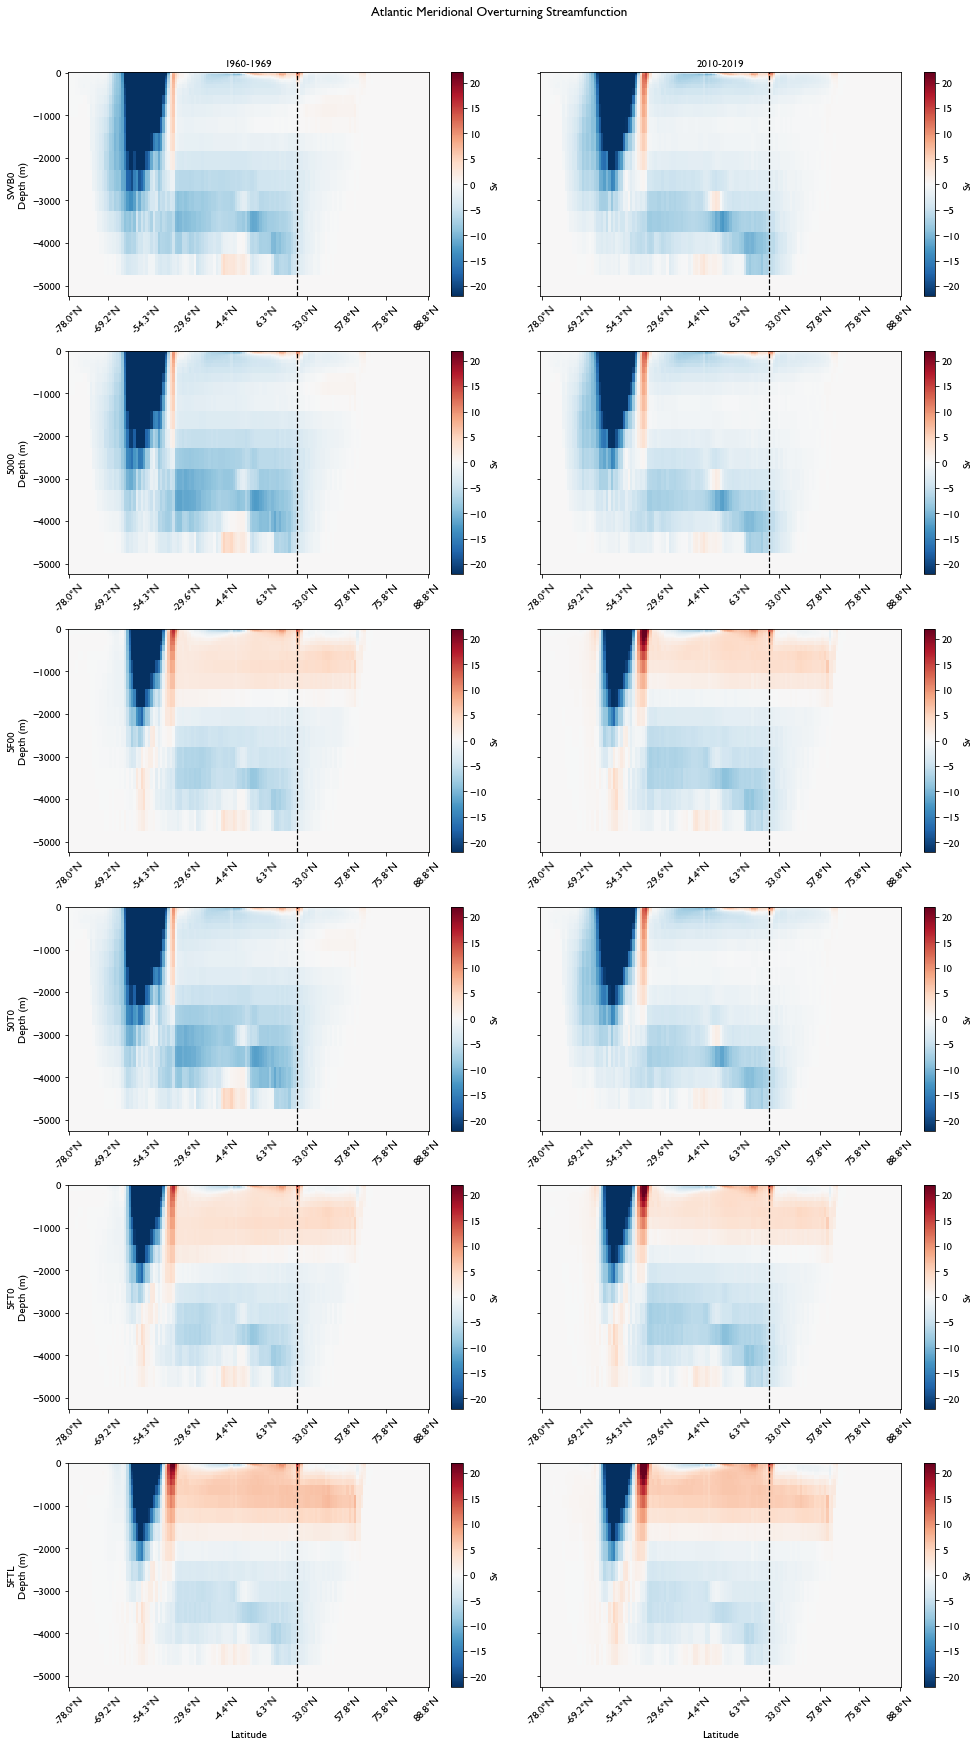

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import numpy as np
import os

# ================================
# FONT CONFIGURATION
# ================================
plt.rcParams['text.usetex'] = False
fs = 11
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

# ================================
# DATA
# ================================
DATA_DIR = '/gpfs/data/greenocean/users/mep22dku/clims'

run_descriptions = {
    "SWB0": "Base year 1990, no flux corr., no temp. corr., spinup from 1920.",
    "5000": "Base year 1950, no flux corr., no temp. corr., spinup from 1920.",
    "5F00": "Base year 1950, flux corr., no temp. corr., spinup from 1920.",
    "50T0": "Base year 1950, no flux corr., temp. corr., spinup from 1920.",
    "5FT0": "Base year 1950, flux corr., temp. corr., spinup from 1920.",
    "5FTL": "Base year 1950, flux corr., temp. corr., spinup from 1800.",
}

periods = {
    '1960-1969': (1960, 1969),
    '2010-2019': (2010, 2019),
}

# Load datasets: datasets[run][period_label] = ds
datasets = {}
for run, desc in run_descriptions.items():
    model = f'TOM12_TJ_{run}'
    datasets[run] = {}
    for label, (yrst, yrend) in periods.items():
        fpath = os.path.join(DATA_DIR, model, f'{model}_SF_{yrst}_{yrend}.nc')
        if os.path.exists(fpath):
            datasets[run][label] = xr.open_dataset(fpath)
        else:
            print(f"Missing: {fpath}")
            datasets[run][label] = None

# ================================
# PLOT  (6 rows x 2 cols)
# ================================
nrows = len(run_descriptions)
ncols = len(periods)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows),
                         sharex=False, sharey=True)

period_labels = list(periods.keys())

for row, (run, desc) in enumerate(run_descriptions.items()):
    for col, period_label in enumerate(period_labels):
        ax  = axes[row, col]
        ds  = datasets[run][period_label]

        if ds is None:
            ax.set_visible(False)
            continue

        y_    = ds['y'].values
        dep_  = ds['depthw'].values
        lats_ = ds['nav_lat'][0, :, 0].values

        idx_26_       = int(np.argmin(np.abs(lats_ - 26.5)))
        tick_indices_ = np.linspace(0, len(y_) - 1, 10, dtype=int)
        ticklabels_   = [f'{lats_[i]:.1f}°N' for i in tick_indices_]

        data = ds['zomsfatl'].values
        pc   = ax.pcolormesh(y_, dep_, data, cmap='RdBu_r', vmin=-22, vmax=22, shading='auto')
        plt.colorbar(pc, ax=ax, label='Sv')

        ax.axvline(x=y_[idx_26_], color='black', linewidth=1.2, linestyle='--', label='26.5°N')
        ax.set_xticks(y_[tick_indices_])
        ax.set_xticklabels(ticklabels_, rotation=45)

        # Left column: y-label with run name; right column: nothing
        if col == 0:
            ax.set_ylabel(f'{run}\nDepth (m)')
        # Top row: period title
        if row == 0:
            ax.set_title(period_label, fontweight='bold')
        # Bottom row: x-label
        if row == nrows - 1:
            ax.set_xlabel('Latitude')

axes[-1, -1].set_xlabel('Latitude')

fig.suptitle('Atlantic Meridional Overturning Streamfunction', fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('./plts', exist_ok=True)
plt.savefig('./plts/SF_6runs_2periods.png', dpi=150, bbox_inches='tight')
plt.show()

## the temperature correction appears not to have made much of a difference, checking that SST looks different in the runs

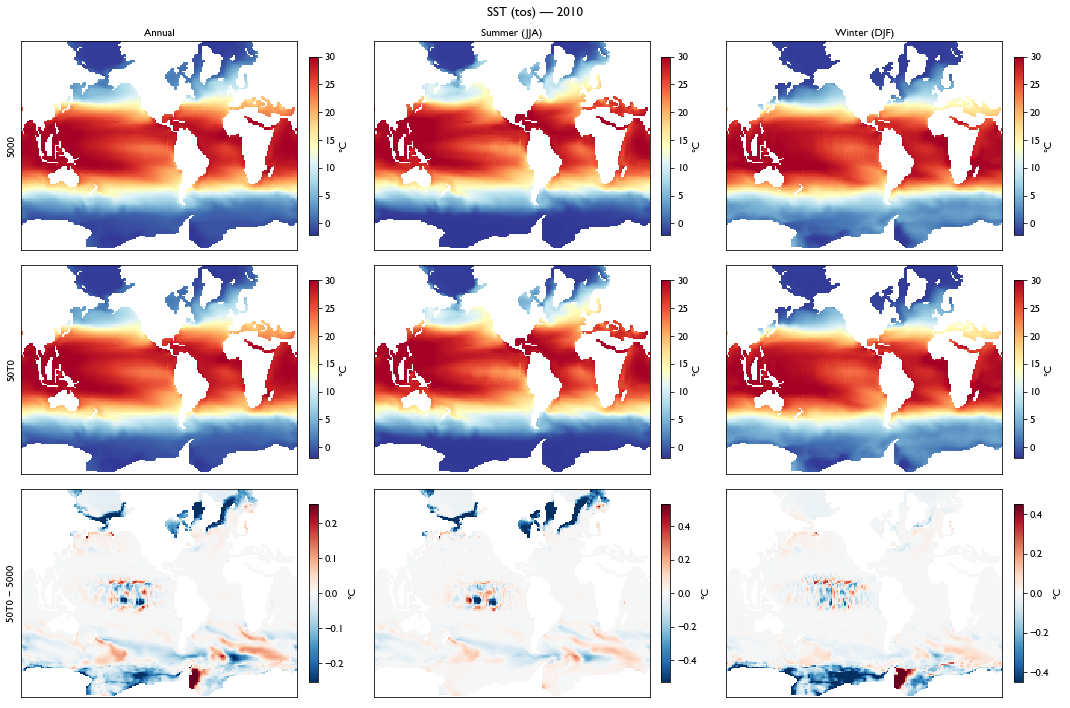

In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# ================================
# CONFIG
# ================================
DATA_DIR = '/gpfs/afm/greenocean/software/runs'
year     = 2010
fname    = f'ORCA2_1m_{year}0101_{year}1231_grid_T.nc'

models = ['TOM12_TJ_5000', 'TOM12_TJ_50T0']

season_months = {
    'Annual':       None,
    'Summer (JJA)': [6, 7, 8],
    'Winter (DJF)': [12, 1, 2],
}

# ================================
# LOAD & COMPUTE SEASONAL MEANS
# ================================
data = {}  # data[model][season] = 2D array
for model in models:
    fpath = f'{DATA_DIR}/{model}/{fname}'
    ds    = xr.open_dataset(fpath)
    tos   = ds['tos']
    data[model] = {}
    for season, months in season_months.items():
        if months is None:
            mean = tos.mean(dim='time_counter')
        else:
            mean = tos.sel(time_counter=tos.time_counter.dt.month.isin(months)).mean(dim='time_counter')
        data[model][season] = mean.where(mean != 0)

# ================================
# PLOT  (3 rows x 3 cols)
# ================================
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

row_labels = [m.replace('TOM12_TJ_', '') for m in models] + ['50T0 − 5000']

for col, season in enumerate(season_months):
    # --- rows 0 & 1: individual models ---
    for row, model in enumerate(models):
        ax = axes[row, col]
        pc = ax.pcolormesh(data[model][season].values, cmap='RdYlBu_r',
                           vmin=-2, vmax=30, shading='auto')
        plt.colorbar(pc, ax=ax, label='°C', fraction=0.03, pad=0.04)
        if row == 0:
            ax.set_title(season, fontweight='bold')
        if col == 0:
            ax.set_ylabel(row_labels[row], fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

    # --- row 2: difference ---
    ax   = axes[2, col]
    diff = data['TOM12_TJ_50T0'][season] - data['TOM12_TJ_5000'][season]
    vlim = np.nanpercentile(np.abs(diff.values), 98)  # symmetric, robust limits
    pc   = ax.pcolormesh(diff.values, cmap='RdBu_r', vmin=-vlim, vmax=vlim, shading='auto')
    plt.colorbar(pc, ax=ax, label='°C', fraction=0.03, pad=0.04)
    if col == 0:
        ax.set_ylabel(row_labels[2], fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'SST (tos) — {year}', fontweight='bold')
plt.tight_layout()
plt.savefig('./plts/SST_5000_50T0_2010.png', dpi=150, bbox_inches='tight')
plt.show()

## what happens at the beginning? 50T1 (50T0 with ice saved)

In [8]:
ice = xr.open_dataset('/gpfs/data/greenocean/software/resources/ModelResources/RestartFiles/restart_ice_v3.6.nc') 
phys = xr.open_dataset('/gpfs/home/hnb15vcu/setUp_TOM12.2_branches/RestartFiles/restart_19191231_opa_PT.nc')

In [20]:
w = xr.open_dataset('/gpfs/home/mep22dku/scratch/ModelRuns/TOM12_TJ_50T1/ORCA2_1m_19200101_19201231_icemod.nc')

w

<xarray.Dataset>
Dimensions:               (axis_nbounds: 2, time_counter: 12, x: 182, y: 149)
Coordinates:
    nav_lat               (y, x) float32 ...
    nav_lon               (y, x) float32 ...
    time_centered         (time_counter) object ...
  * time_counter          (time_counter) object 1920-01-16 12:00:00 ... 1920-...
Dimensions without coordinates: axis_nbounds, x, y
Data variables: (12/14)
    ice_pres              (time_counter, y, x) float32 ...
    time_centered_bounds  (time_counter, axis_nbounds) object ...
    time_counter_bounds   (time_counter, axis_nbounds) object ...
    snd                   (time_counter, y, x) float32 ...
    sit                   (time_counter, y, x) float32 ...
    sip                   (time_counter, y, x) float32 ...
    ...                    ...
    vice_ipa              (time_counter, y, x) float32 ...
    utau_ice              (time_counter, y, x) float32 ...
    vtau_ice              (time_counter, y, x) float32 ...
    qsr_io_cea            (time_counter, y, x) float32 ...
    qns_io_cea            (time_counter, y, x) float32 ...
    snowpre               (time_counter, y, x) float32 ...
Attributes:
    name:         ORCA2_1m_19200101_19201231
    description:  ice variables
    title:        ice variables
    Conventions:  CF-1.5
    production:   An IPSL model
    timeStamp:    2026-Apr-10 16:38:54 BST

/gpfs/home/mep22dku/.conda/envs/swamp2/lib/python3.7/site-packages/ipykernel_launcher.py:17: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations


Saved sos_36months.png


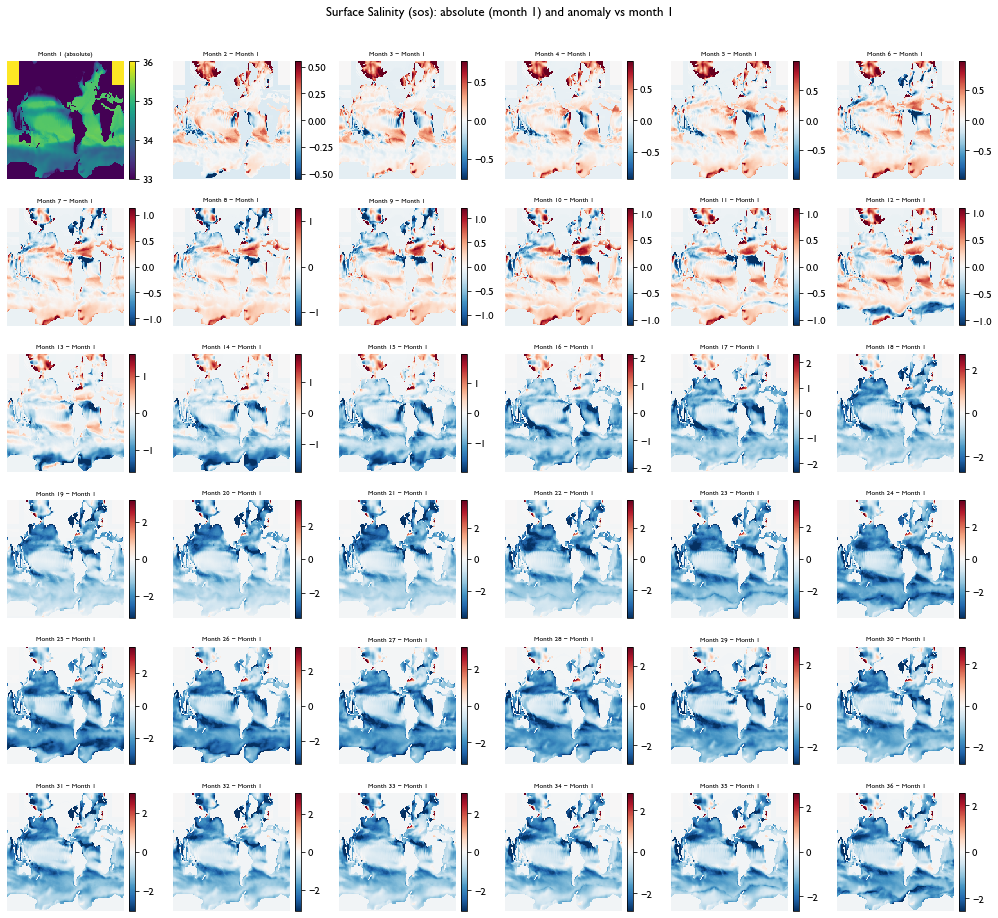

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import os

data_dir = "/gpfs/home/mep22dku/scratch/ModelRuns/TOM12_TJ_50T1"
files = [
    "ORCA2_1m_19200101_19201231_grid_T.nc",
    "ORCA2_1m_19210101_19211231_grid_T.nc",
    "ORCA2_1m_19220101_19221231_grid_T.nc",
]

# Load all 36 months of sos
sos_all = []
for fname in files:
    with nc.Dataset(os.path.join(data_dir, fname)) as ds:
        sos = ds.variables["sos"][:]  # shape: (12, y, x)
        for t in range(sos.shape[0]):
            sos_all.append(np.array(sos[t]))

sos_all = np.array(sos_all)  # (36, y, x)
ref = sos_all[0]              # first month, used as reference

fact = 0.7
fig, axes = plt.subplots(6, 6, figsize=(20*fact, 18*fact))
axes = axes.flatten()

for i in range(36):
    ax = axes[i]
    if i == 0:
        data = sos_all[0]
        label = "Month 1 (absolute)"
        cmap = "viridis"
        vmin, vmax = 33, 36
    else:
        data = sos_all[i] - ref
        label = f"Month {i+1} − Month 1"
        cmap = "RdBu_r"
        absmax = np.nanpercentile(np.abs(data), 98)
        vmin, vmax = -absmax, absmax

    im = ax.imshow(data, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation="nearest", aspect="auto")
    ax.set_title(label, fontsize=7)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Surface Salinity (sos): absolute (month 1) and anomaly vs month 1", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sos_36months.png", dpi=150, bbox_inches="tight")
print("Saved sos_36months.png")

/gpfs/home/mep22dku/.conda/envs/swamp2/lib/python3.7/site-packages/ipykernel_launcher.py:17: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations


Saved ice_pres_36months.png


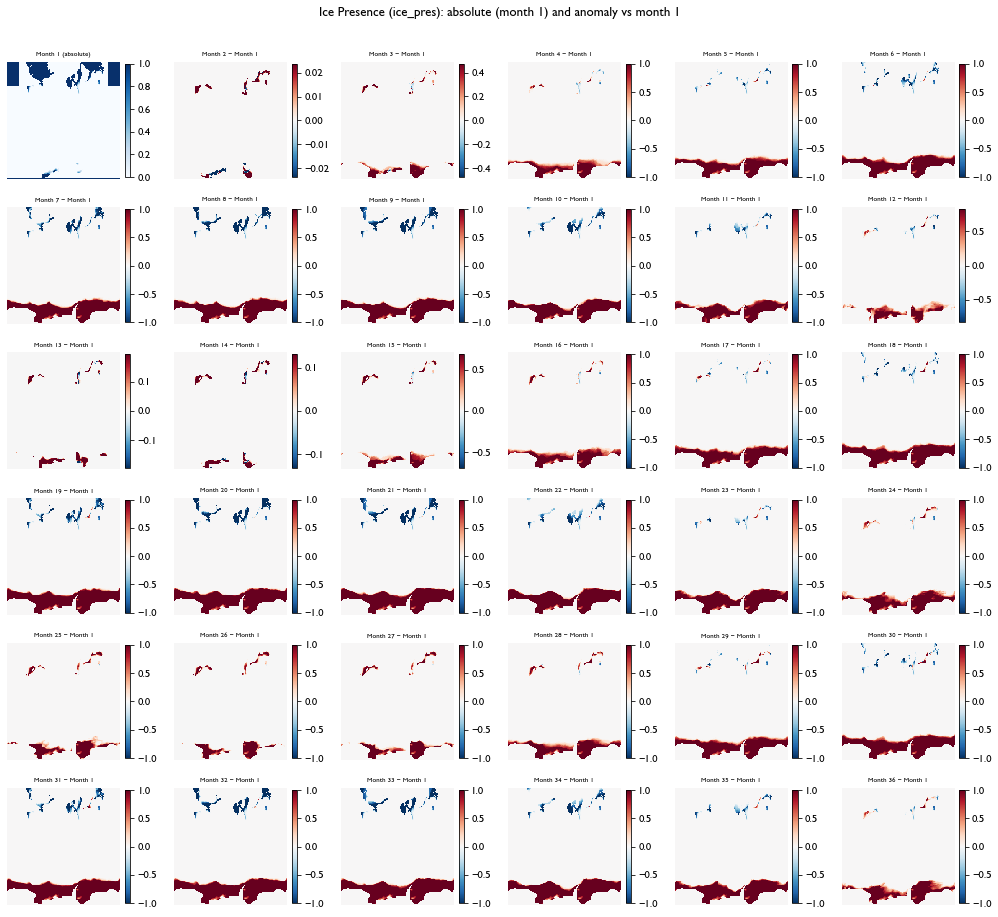

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import os

data_dir = "/gpfs/home/mep22dku/scratch/ModelRuns/TOM12_TJ_50T1"
files = [
    "ORCA2_1m_19200101_19201231_icemod.nc",
    "ORCA2_1m_19210101_19211231_icemod.nc",
    "ORCA2_1m_19220101_19221231_icemod.nc",
]

# Load all 36 months of ice_pres
ice_all = []
for fname in files:
    with nc.Dataset(os.path.join(data_dir, fname)) as ds:
        ice = ds.variables["ice_pres"][:]  # shape: (12, y, x)
        for t in range(ice.shape[0]):
            ice_all.append(np.array(ice[t]))

ice_all = np.array(ice_all)  # (36, y, x)
ref = ice_all[0]              # first month, used as reference

fact = 0.7
fig, axes = plt.subplots(6, 6, figsize=(20*fact, 18*fact))
axes = axes.flatten()

for i in range(36):
    ax = axes[i]
    if i == 0:
        data = ice_all[0]
        label = "Month 1 (absolute)"
        cmap = "Blues"
        vmin, vmax = 0, 1
    else:
        data = ice_all[i] - ref
        label = f"Month {i+1} − Month 1"
        cmap = "RdBu_r"
        absmax = np.nanpercentile(np.abs(data), 98)
        vmin, vmax = -absmax, absmax

    im = ax.imshow(data, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation="nearest", aspect="auto")
    ax.set_title(label, fontsize=7)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Ice Presence (ice_pres): absolute (month 1) and anomaly vs month 1", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("ice_pres_36months.png", dpi=150, bbox_inches="tight")
print("Saved ice_pres_36months.png")

## ice anomaly

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import os
from datetime import datetime
from dateutil.relativedelta import relativedelta

data_dir = "/gpfs/home/mep22dku/scratch/ModelRuns/TOM12_TJ_50T1"
out_dir  = "./plts/iceprog"
os.makedirs(out_dir, exist_ok=True)

sos_files = [
    "ORCA2_1m_19200101_19201231_grid_T.nc",
    "ORCA2_1m_19210101_19211231_grid_T.nc",
    "ORCA2_1m_19220101_19221231_grid_T.nc",
    "ORCA2_1m_19230101_19231231_grid_T.nc",
    "ORCA2_1m_19240101_19241231_grid_T.nc",
    "ORCA2_1m_19250101_19251231_grid_T.nc",
    "ORCA2_1m_19260101_19261231_grid_T.nc",
]
ice_files = [
    "ORCA2_1m_19200101_19201231_icemod.nc",
    "ORCA2_1m_19210101_19211231_icemod.nc",
    "ORCA2_1m_19220101_19221231_icemod.nc",
    "ORCA2_1m_19230101_19231231_icemod.nc",
    "ORCA2_1m_19240101_19241231_icemod.nc",
    "ORCA2_1m_19250101_19251231_icemod.nc",
    "ORCA2_1m_19260101_19261231_icemod.nc",
]

# ── load all 36 months ────────────────────────────────────────────────────────
sos_all, ice_all = [], []
for sf, icf in zip(sos_files, ice_files):
    with nc.Dataset(os.path.join(data_dir, sf)) as ds:
        sos = ds.variables["sos"][:]
        for t in range(sos.shape[0]):
            sos_all.append(np.array(sos[t]))
    with nc.Dataset(os.path.join(data_dir, icf)) as ds:
        ice = ds.variables["ice_pres"][:]
        for t in range(ice.shape[0]):
            ice_all.append(np.array(ice[t]))

sos_all = np.array(sos_all)   # (36, y, x)
ice_all = np.array(ice_all)   # (36, y, x)
sos_ref = sos_all[0]
ice_ref = ice_all[0]

# anomaly colour scale: fix it across all frames for a stable movie
sos_anom_lim = max(abs(np.nanpercentile(sos_all[1:] - sos_ref, 1)),
                   abs(np.nanpercentile(sos_all[1:] - sos_ref, 99)))
ice_anom_lim = max(abs(np.nanpercentile(ice_all[1:] - ice_ref, 1)),
                   abs(np.nanpercentile(ice_all[1:] - ice_ref, 99)))

# ── timestamp list (monthly from Jan 1920) ────────────────────────────────────
t0 = datetime(1920, 1, 1)
timestamps = [t0 + relativedelta(months=i) for i in range(84)]

# ── plot ──────────────────────────────────────────────────────────────────────
imshow_kw = dict(origin="lower", interpolation="nearest", aspect="auto")

for i in range(84):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ts = timestamps[i].strftime("%B %Y")
    fig.suptitle(ts, fontsize=15, fontweight="bold")

    # ── top left: absolute salinity ───────────────────────────────────────────
    ax = axes[0, 0]
    im = ax.imshow(sos_all[i], cmap="viridis", vmin=34, vmax=36, **imshow_kw)
    ax.set_title("Salinity (psu)", fontsize=10)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ── top right: absolute ice presence ─────────────────────────────────────
    ax = axes[0, 1]
    im = ax.imshow(ice_all[i], cmap="Blues", vmin=0, vmax=1, **imshow_kw)
    ax.set_title("Ice Presence (fraction)", fontsize=10)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ── bottom left: salinity anomaly ─────────────────────────────────────────
    ax = axes[1, 0]
    if i == 0:
        ax.text(0.5, 0.5, "Reference month\n(no anomaly)", ha="center",
                va="center", transform=ax.transAxes, fontsize=12)
        ax.axis("off")
    else:
        im = ax.imshow(sos_all[i] - sos_ref, cmap="RdBu_r",
                       vmin=-sos_anom_lim, vmax=sos_anom_lim, **imshow_kw)
        ax.set_title("Salinity anomaly vs Month 1 (psu)", fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ── bottom right: ice anomaly ─────────────────────────────────────────────
    ax = axes[1, 1]
    if i == 0:
        ax.text(0.5, 0.5, "Reference month\n(no anomaly)", ha="center",
                va="center", transform=ax.transAxes, fontsize=12)
        ax.axis("off")
    else:
        im = ax.imshow(ice_all[i] - ice_ref, cmap="RdBu_r",
                       vmin=-ice_anom_lim, vmax=ice_anom_lim, **imshow_kw)
        ax.set_title("Ice presence anomaly vs Month 1", fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fname = os.path.join(out_dir, f"frame_{i:03d}.jpg")
    plt.savefig(fname, dpi=150, bbox_inches="tight", quality=92)
    plt.close(fig)
    print(f"Saved {fname}  ({ts})")

print("Done.")

/gpfs/home/mep22dku/.conda/envs/swamp2/lib/python3.7/site-packages/ipykernel_launcher.py:35: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
/gpfs/home/mep22dku/.conda/envs/swamp2/lib/python3.7/site-packages/ipykernel_launcher.py:39: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
/gpfs/home/mep22dku/.conda/envs/swamp2/lib/python3.7/site-packages/ipykernel

Saved ./plts/iceprog/frame_000.jpg  (January 1920)
Saved ./plts/iceprog/frame_001.jpg  (February 1920)
Saved ./plts/iceprog/frame_002.jpg  (March 1920)
Saved ./plts/iceprog/frame_003.jpg  (April 1920)
Saved ./plts/iceprog/frame_004.jpg  (May 1920)
Saved ./plts/iceprog/frame_005.jpg  (June 1920)
Saved ./plts/iceprog/frame_006.jpg  (July 1920)
Saved ./plts/iceprog/frame_007.jpg  (August 1920)
Saved ./plts/iceprog/frame_008.jpg  (September 1920)
Saved ./plts/iceprog/frame_009.jpg  (October 1920)
Saved ./plts/iceprog/frame_010.jpg  (November 1920)
Saved ./plts/iceprog/frame_011.jpg  (December 1920)
Saved ./plts/iceprog/frame_012.jpg  (January 1921)
Saved ./plts/iceprog/frame_013.jpg  (February 1921)
Saved ./plts/iceprog/frame_014.jpg  (March 1921)
Saved ./plts/iceprog/frame_015.jpg  (April 1921)
Saved ./plts/iceprog/frame_016.jpg  (May 1921)
Saved ./plts/iceprog/frame_017.jpg  (June 1921)
Saved ./plts/iceprog/frame_018.jpg  (July 1921)
Saved ./plts/iceprog/frame_019.jpg  (August 1921)
Save